# Choosing a strategy

The previous pages showed *how* to call each tool. This one is about *which* to reach for. There
is no single best optimiser — the right choice falls out of four questions about your situation.
The worked, end-to-end investor profiles live in
[putting it together](../examples/7_putting_it_together/01_Profile_Retail_Daily.md); this page is
the decision framework behind them.

## The four questions

1. **How much compute can you spend per rebalance?** Naive optimisers (`InverseVolatility`,
   `EqualWeighted`) are instant and solver-free. JuMP optimisers (`MeanRisk`,
   `RiskBudgeting`) solve a convex program — fast, but not free. Meta-optimisers
   (`NestedClustered`, `Stacking`) and cross-validated tuning stack many solves
   and cost the most.

2. **How often do you rebalance?** High frequency rewards cheap, stable rules and tight
   `Turnover`/`Fees` control so costs do not eat the edge. Infrequent rebalancing
   can afford a heavier, more bespoke optimisation each time.

3. **How much do you trust your estimates?** If you have genuine forecasts, fold them in with a
   view prior (`BlackLittermanPrior`, `EntropyPoolingPrior`). If you mostly
   distrust the noise in the moments, make the optimisation robust (`UncertaintySetVariance`,
   a worst-case mean) or lean on the correlation hierarchy (`HierarchicalRiskParity`)
   rather than point estimates.

4. **How large and constrained is the capital?** Small accounts need
   `GreedyAllocation` to round into whole shares without wasting cash. Institutional
   mandates pile on constraints — weight bounds, group limits, tracking — which is exactly what
   the JuMP optimisers are built for.

## A rough map

| Situation | Reach for |
|:--|:--|
| Minimal compute, just want diversification | `InverseVolatility` / `EqualWeighted` |
| Classic risk/return trade-off | `MeanRisk` with an objective + efficient frontier |
| Want each holding to carry equal risk | `RiskBudgeting` |
| Many assets, unstable covariance | `HierarchicalRiskParity` and clustering optimisers |
| Distrust a single fit, want robustness | `NestedClustered` / `Stacking`, or uncertainty sets |
| Have real views | `BlackLittermanPrior` / `EntropyPoolingPrior` |
| Tight rebalancing budget | add `Turnover` / `Fees` to a `JuMPOptimiser` |
| Trading real money | finish with `GreedyAllocation` |

These are starting points, not rules — most real strategies combine several (a view prior *and*
constraints *and* finite allocation). The
[putting-it-together profiles](../examples/7_putting_it_together/01_Profile_Retail_Daily.md) walk
three complete examples end to end.

## The choice is real

To make the point concrete: three archetypes from the map — pure diversification, the
risk/return workhorse, and the hierarchy-based rule — produce visibly different portfolios on the
same data. Picking a strategy is picking one of these shapes.

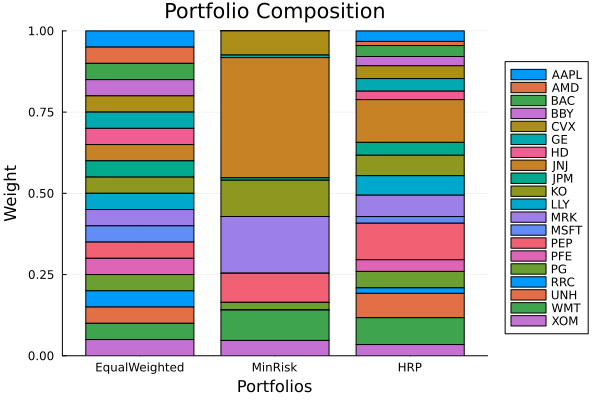

In [1]:
using PortfolioOptimisers, CSV, TimeSeries, Clarabel, StatsPlots, GraphRecipes

X = TimeArray(CSV.File(joinpath(@__DIR__, "../examples/SP500.csv.gz")); timestamp = :Date)[(end - 252):end]
rd = prices_to_returns(X)
pr = prior(EmpiricalPrior(), rd)

slv = Solver(; name = :clarabel, solver = Clarabel.Optimizer,
             settings = Dict("verbose" => false),
             check_sol = (; allow_local = true, allow_almost = true))

res_ew = optimise(EqualWeighted(), rd)
res_mr = optimise(MeanRisk(; obj = MinimumRisk(), opt = JuMPOptimiser(; pe = pr, slv = slv)))
res_hrp = optimise(HierarchicalRiskParity(; r = Variance(),
                                          opt = HierarchicalOptimiser(; pe = pr,
                                                                      cle = clusterise(ClustersEstimator(),
                                                                                       pr.X))))

plot_stacked_bar_composition([res_ew, res_mr, res_hrp], rd;
                             xticks = (1:3, ["EqualWeighted", "MinRisk", "HRP"]))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*